# FMATCH 2/10 — Ancillary reader framework & gridded readers

**PR topic**: the plugin architecture that turns heterogeneous external datasets into
uniform spatial tiles, plus the six *gridded* ancillary readers:

| reader key | dataset | format |
|---|---|---|
| `era5` | ERA5 single-level reanalysis (winds + 5 IMAGER fields) | NetCDF4 |
| `era5_pressure` | ERA5 pressure-level fields (37 levels) | NetCDF4 |
| `igbp` | IGBP land cover (MODIS, sinusoidal grid) | HDF4 |
| `nise` | NSIDC NISE snow/ice (EASE-Grid, both hemispheres) | HDF-EOS4 |
| `viirs_aod` | VIIRS Deep Blue aerosol (AERDB_D3_VIIRS_NOAA20) | NetCDF4 |
| `viirs_brdf` | VIIRS BRDF (VJ143C1) | HDF-EOS5 |

The swath-product readers (CERES SSF, CLDPIX, VIIRS cloud) arrive in the **next PR**
of this stack.

**Architecture in one paragraph**: every reader subclasses `GriddedDataReader` and
declares `READER_KEY`, `INSTRUMENT`, `RESOLUTION_KM`, and a `VARIABLES` tuple of
`VariableSpec`s. Subclassing auto-registers the reader in `ReaderRegistry`
(`__init_subclass__` hook) — no central list to maintain. `load_tile(TileKey)` is a
template method: it converts the tile key to a lat/lon `BoundingBox` and delegates to
the subclass's `_load_spatial_region`. The heavy geospatial stack (`pyproj`, `pyhdf`,
`h5py`) is behind the optional `fmatch` extra and imported lazily, so a core-only
install still imports cleanly.

In [1]:
import sys
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Notebook lives in doc/notebooks/; the synthetic-fixture generators live in tests/.
repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

In [2]:
import libera_utils.footprint_matching.readers  # noqa: F401  (import triggers registration)
from libera_utils.footprint_matching.readers.registry import ReaderRegistry
from libera_utils.footprint_matching.types import TileKey

## 1. The registry: readers self-register on import

Importing the `readers` package defines every reader class, and defining a
`GriddedDataReader` subclass registers it. Downstream code never imports concrete
readers — it asks the registry by key.

In [3]:
print(ReaderRegistry.list_readers())

['era5', 'era5_pressure', 'igbp', 'nise', 'viirs_aod', 'viirs_brdf']


## 2. The read/product contract per reader

`VARIABLES` is what a reader reads from its file; `product_variable_specs()` is what
it contributes to the FMATCH product definition — the read variables plus
automatically-inserted `_standard_deviation` companions for continuous fields plus
derived outputs (e.g. IGBP's ranked scene types). One method keeps readers, YAMLs,
and tests agreeing on the exact names.

In [4]:
rows = []
for key in ReaderRegistry.list_readers():
    reader_cls = ReaderRegistry.get(key)
    rows.append(
        {
            "reader": key,
            "instrument": reader_cls.INSTRUMENT,
            "resolution_km": reader_cls.RESOLUTION_KM,
            "read_vars": len(reader_cls.VARIABLES),
            "product_vars": len(reader_cls.product_variable_specs()),
        }
    )
pd.DataFrame(rows).set_index("reader")

,instrument,resolution_km,read_vars,product_vars
reader,,,,
era5,ECMWF,25.0,7,14
era5_pressure,ECMWF,25.0,185,370
igbp,MODIS,1.0,1,4
nise,SSMIS,25.0,5,10
viirs_aod,NOAA20,111.0,2,6
viirs_brdf,NOAA20,5.6,9,18


In [5]:
era5_cls = ReaderRegistry.get("era5")
for spec in era5_cls.product_variable_specs():
    print(f"era5_{spec.name}")

era5_wind_u10
era5_wind_u10_standard_deviation
era5_wind_v10
era5_wind_v10_standard_deviation
era5_temperature_2m
era5_temperature_2m_standard_deviation
era5_dew_point_temperature_2m
era5_dew_point_temperature_2m_standard_deviation
era5_surface_pressure
era5_surface_pressure_standard_deviation
era5_surface_geopotential
era5_surface_geopotential_standard_deviation
era5_forecast_albedo
era5_forecast_albedo_standard_deviation


## 3. Reading a tile: ERA5

Below we write a synthetic ERA5 single-levels file (same structure and conventions as
a real CDS download, including the *descending* latitude axis) with the fixture
factory the unit tests use, then ask the reader for 2°×2° tiles. `TileKey(source,
lat_idx, lon_idx)` indexes the global 2° grid: `lat_idx = (lat + 90) / 2`,
`lon_idx = (lon + 180) / 2`.

In [6]:
from tests.test_data.footprint_matching.fixtures import (
    make_aod_noaa20_fixture,
    make_era5_netcdf_fixture,
    make_viirs_brdf_hdf5_fixture,
)

workdir = Path(tempfile.mkdtemp(prefix="fmatch_nb02_"))
era5_path = make_era5_netcdf_fixture(workdir, lat_min=0.0, lat_max=8.0, lon_min=10.0, lon_max=18.0, n_lat=33, n_lon=33)

era5 = era5_cls(era5_path)
tile = era5.load_tile(TileKey("era5", lat_idx=46, lon_idx=96))  # lat [2,4], lon [12,14]
print(f"source={tile.source}  data shape={tile.data.shape}  (variables, lat, lon)")
print(f"bounds: lat [{tile.bounds.lat_min}, {tile.bounds.lat_max}]  lon [{tile.bounds.lon_min}, {tile.bounds.lon_max}]")

source=era5  data shape=(7, 9, 9)  (variables, lat, lon)
bounds: lat [2.0, 4.0]  lon [12.0, 14.0]


The fixture writes smooth synthetic wind fields; the tile carries the variables on
axis 0 in `VARIABLES` order, plus its own coordinate arrays — everything the
aggregation stage needs, with no knowledge of the source file format.

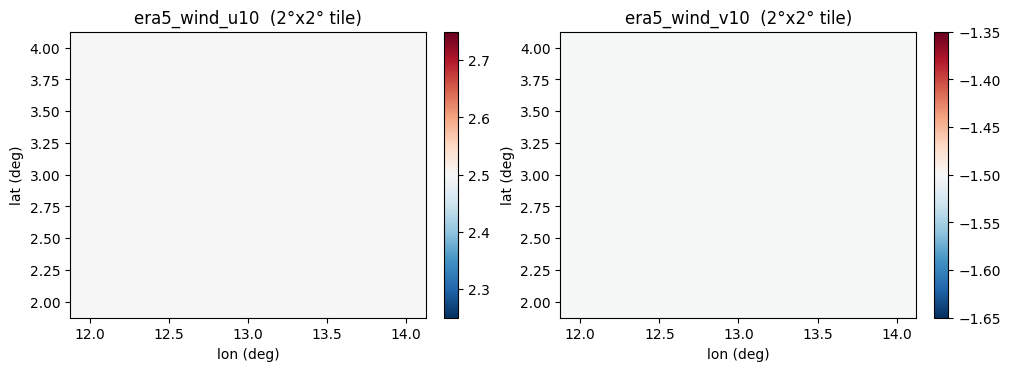

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), constrained_layout=True)
for ax, var_idx in zip(axes, (0, 1), strict=True):
    im = ax.pcolormesh(tile.lons, tile.lats, tile.data[var_idx], shading="auto", cmap="RdBu_r")
    ax.set_title(f"era5_{era5_cls.VARIABLES[var_idx].name}  (2°x2° tile)")
    ax.set_xlabel("lon (deg)")
    ax.set_ylabel("lat (deg)")
    fig.colorbar(im, ax=ax)
plt.show()

## 4. Same interface, different formats: VIIRS AOD (NetCDF) and BRDF (HDF-EOS5)

The point of the template-method design: the tile a caller gets back looks identical
regardless of whether the source was a NetCDF file at the root level, an HDF-EOS5
group hierarchy, or (for IGBP/NISE) an HDF4 sinusoidal / EASE-Grid projection that
must be rasterized to lat/lon first.

In [8]:
aod_path = make_aod_noaa20_fixture(workdir, n_lat=16, n_lon=16, lat_min=0.5, lat_max=7.5, lon_min=10.5, lon_max=17.5)
aod = ReaderRegistry.get("viirs_aod")(aod_path)
aod_tile = aod.load_tile(TileKey("viirs_aod", 46, 96))
print(f"viirs_aod tile: shape={aod_tile.data.shape}, aod_550 mean={np.nanmean(aod_tile.data[0]):.3f}")

brdf_path = make_viirs_brdf_hdf5_fixture(
    workdir, n_lat=40, n_lon=40, lat_min=2.0, lat_max=4.0, lon_min=12.0, lon_max=14.0
)
brdf = ReaderRegistry.get("viirs_brdf")(brdf_path)
brdf_tile = brdf.load_tile(TileKey("viirs_brdf", 46, 96))
print(f"viirs_brdf tile: shape={brdf_tile.data.shape} (9 BRDF kernel params on axis 0)")

viirs_aod tile: shape=(2, 4, 4), aod_550 mean=0.200
viirs_brdf tile: shape=(9, 40, 40) (9 BRDF kernel params on axis 0)


## 5. Projected-grid readers: IGBP and NISE

IGBP (MODIS sinusoidal HDF4) and NISE (EASE-Grid HDF-EOS4, northern + southern
hemisphere grids concatenated as point clouds) cannot be sliced directly in lat/lon —
their readers reproject/rasterize the native grid onto the tile with the shared
`rasterize_points_to_grid` helper from `_swath.py`. Their unit tests exercise this
through a monkeypatched read seam (writing real HDF4 requires the HDF4 C library),
so here we just show their declared contracts; see
`tests/unit/test_footprint_matching/test_readers/test_igbp.py` / `test_nsidc.py`.

In [9]:
for key in ("igbp", "nise"):
    cls = ReaderRegistry.get(key)
    names = [f"{key}_{s.name}" for s in cls.product_variable_specs()]
    print(f"{key:5s} ({cls.INSTRUMENT}, {cls.RESOLUTION_KM} km): {', '.join(names)}")

igbp  (MODIS, 1.0 km): igbp_surface_type, igbp_surface_type_primary, igbp_surface_type_secondary, igbp_surface_type_tertiary
nise  (SSMIS, 25.0 km): nise_sea_ice_concentration, nise_sea_ice_concentration_standard_deviation, nise_no_ice_or_snow, nise_no_ice_or_snow_standard_deviation, nise_permanent_ice, nise_permanent_ice_standard_deviation, nise_dry_snow_on_land, nise_dry_snow_on_land_standard_deviation, nise_snow_ice_missing, nise_snow_ice_missing_standard_deviation


## Where this goes next in the stack

- **PR 3** adds the swath readers (CERES SSF, CLDPIX, VIIRS cloud) and the final
  registry with all nine readers.
- **PR 4** adds the `TileManager`, which owns *which* `TileKey`s to request for a
  footprint `BoundingBox` (from PR 1) and caches the resulting `GridTile`s.
- The `VariableSpec` contracts shown above become the FMATCH product definitions in
  **PR 6**.